# Analyse des avis Abritel — Preuves empiriques et analyse quantitative

**Corpus** : 725 avis collectés sur Google Play, App Store et Trustpilot (janvier 2025 — avril 2026).

**Catégorisation** : approche hybride mots-clés + validation LLM (Ollama gemma4:31b, température 0).

**Structure du notebook** :
1. Vue d'ensemble du corpus
2. Preuves empiriques — problèmes identifiés par persona
3. Analyses quantitatives — 4 questions de recherche avec tests statistiques
4. Résultats — matrice de priorisation et synthèse chiffrée

Les figures sont exportées en PNG (300 DPI) dans `data/figures/` pour le PowerPoint.

In [1]:
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import simplemma
from scipy import stats
from wordcloud import WordCloud

matplotlib.rcParams.update(
    {
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "font.family": "sans-serif",
        "font.size": 11,
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
    }
)

FIGURES = Path("data/figures")
FIGURES.mkdir(exist_ok=True)

PAL_CAT = {
    "Financier": "#e74c3c",
    "Qualité du bien": "#e67e22",
    "Localisation / Langue": "#3498db",
    "Annulation / Réservation": "#9b59b6",
    "Service Client": "#1abc9c",
    "Bug Technique": "#34495e",
    "UX / Ergonomie": "#f39c12",
    "Autre": "#bdc3c7",
}

## 1. Vue d'ensemble du corpus

In [2]:
df = pd.read_csv("data/avis_enrichis.csv", encoding="utf-8-sig")
neg = df[df["type_avis"] == "négatif"]
loc_neg = neg[neg["profil_auteur"] == "Locataire"]
prop_neg = neg[neg["profil_auteur"] == "Propriétaire"]

print(f"Corpus : {len(df)} avis | {len(neg)} négatifs ({len(neg) / len(df) * 100:.0f}%)")
print(
    f"  Locataire    : {len(loc_neg)} négatifs sur {len(df[df['profil_auteur'] == 'Locataire'])} avis"
)
print(
    f"  Propriétaire : {len(prop_neg)} négatifs sur {len(df[df['profil_auteur'] == 'Propriétaire'])} avis"
)
print()
print("Répartition par source :")
for src in df["source"].value_counts().index:
    src_df = df[df["source"] == src]
    src_neg = len(src_df[src_df["type_avis"] == "négatif"])
    print(
        f"  {src:15s} : {len(src_df):3d} avis, {src_neg:3d} négatifs ({src_neg / len(src_df) * 100:.0f}%)"
    )

Corpus : 726 avis | 487 négatifs (67%)
  Locataire    : 443 négatifs sur 682 avis
  Propriétaire : 44 négatifs sur 44 avis

Répartition par source :
  Google Play     : 469 avis, 233 négatifs (50%)
  Trustpilot      : 206 avis, 206 négatifs (100%)
  App Store       :  51 avis,  48 négatifs (94%)


In [3]:
# --- Accord inter-annotateurs (Cohen's Kappa) ---
if "Catégorie_mots_cles" in df.columns and "Catégorie_ollama" in df.columns:
    mask_k = df["Catégorie_ollama"].notna() & (df["Catégorie_ollama"].astype(str).str.strip() != "")
    sub_k = df[mask_k]
    y1 = sub_k["Catégorie_mots_cles"].astype(str).tolist()
    y2 = sub_k["Catégorie_ollama"].astype(str).tolist()
    n_k = len(y1)
    cats_k = sorted(set(y1) | set(y2))
    p_o = sum(1 for a, b in zip(y1, y2, strict=True) if a == b) / n_k
    p_e = sum(
        (sum(1 for x in y1 if x == c) / n_k) * (sum(1 for x in y2 if x == c) / n_k) for c in cats_k
    )
    kappa = (p_o - p_e) / (1 - p_e) if p_e < 1.0 else 1.0
    n_reclassified = (sub_k["Catégorie_mots_cles"] != sub_k["Catégorie_ollama"]).sum()
    interp = (
        "faible"
        if kappa < 0.4
        else "modéré"
        if kappa < 0.6
        else "substantiel"
        if kappa < 0.8
        else "excellent"
    )
    print(f"Accord inter-annotateurs (Cohen's κ) : {kappa:.3f} ({interp})")
    print(f"  Accord observé : {p_o:.1%} | Accord attendu (hasard) : {p_e:.1%}")
    print(
        f"  Avis reclassifiés par le LLM : {n_reclassified}/{n_k} ({n_reclassified / n_k * 100:.0f}%)"
    )
else:
    kappa = None
    print("Colonnes Catégorie_mots_cles / Catégorie_ollama absentes — Kappa non calculable.")

Accord inter-annotateurs (Cohen's κ) : 0.663 (substantiel)
  Accord observé : 71.1% | Accord attendu (hasard) : 14.2%
  Avis reclassifiés par le LLM : 210/726 (29%)


---
## 2. Preuves empiriques

### 2.1 Biais de sélection par source

Trustpilot ne capte que les utilisateurs mécontents (100% négatif), tandis que Google Play offre un échantillon plus équilibré. Cette triangulation renforce la validité des problèmes identifiés : si un problème apparaît sur les 3 sources, il est structurel.

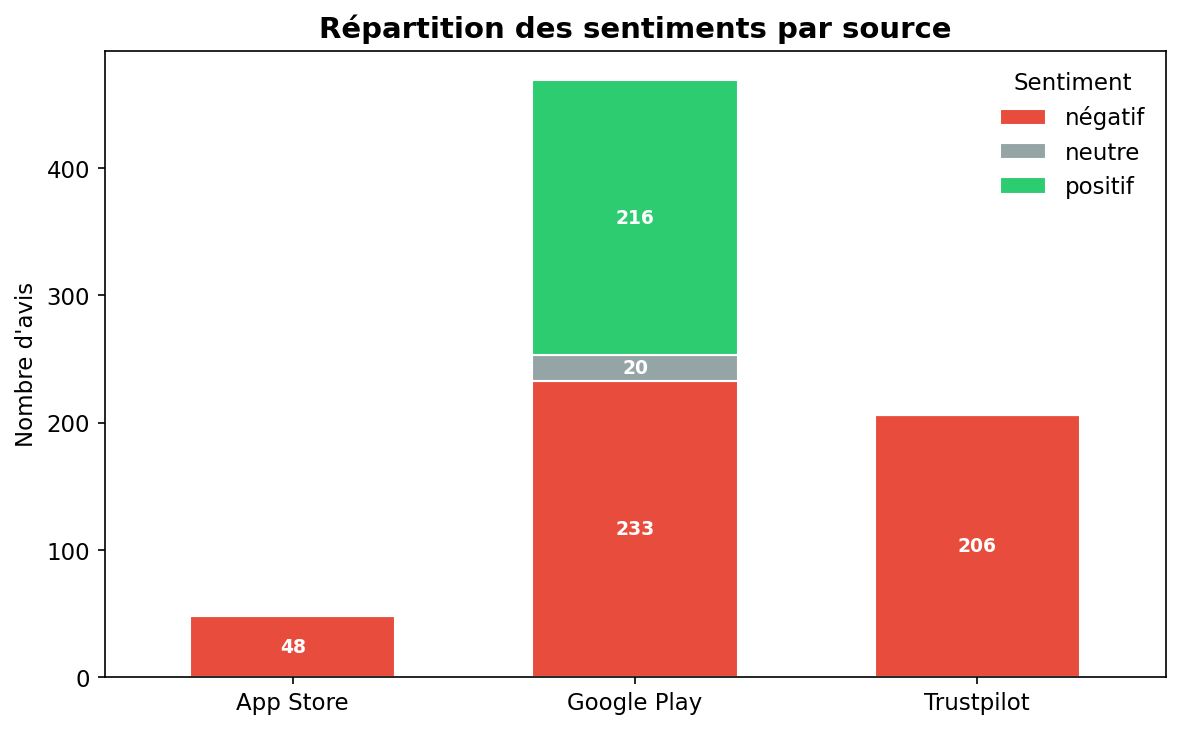

In [4]:
fig1, ax1 = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df["source"], df["type_avis"])
ct = ct.reindex(columns=["négatif", "neutre", "positif"])
colors_sent = ["#e74c3c", "#95a5a6", "#2ecc71"]
ct.plot.bar(stacked=True, ax=ax1, color=colors_sent, edgecolor="white", width=0.6)
ax1.set_title("Répartition des sentiments par source")
ax1.set_xlabel("")
ax1.set_ylabel("Nombre d'avis")
ax1.legend(title="Sentiment", frameon=False)
ax1.tick_params(axis="x", rotation=0)
for container in ax1.containers:
    labels = [f"{int(v.get_height())}" if v.get_height() > 5 else "" for v in container]
    ax1.bar_label(
        container, labels=labels, label_type="center", fontsize=9, color="white", fontweight="bold"
    )
fig1.tight_layout()
fig1.savefig(FIGURES / "fig1_sentiments_source.png", bbox_inches="tight")
plt.show()

### 2.2 Top problèmes — Locataire (n=443 avis négatifs)

Les catégories sont issues d'une classification hybride : détection par mots-clés (normalisation NFD, sans accents) puis validation par LLM (gemma4:31b, température 0 pour la reproductibilité). La catégorie « Autre » (avis trop courts ou vagues) est exclue.

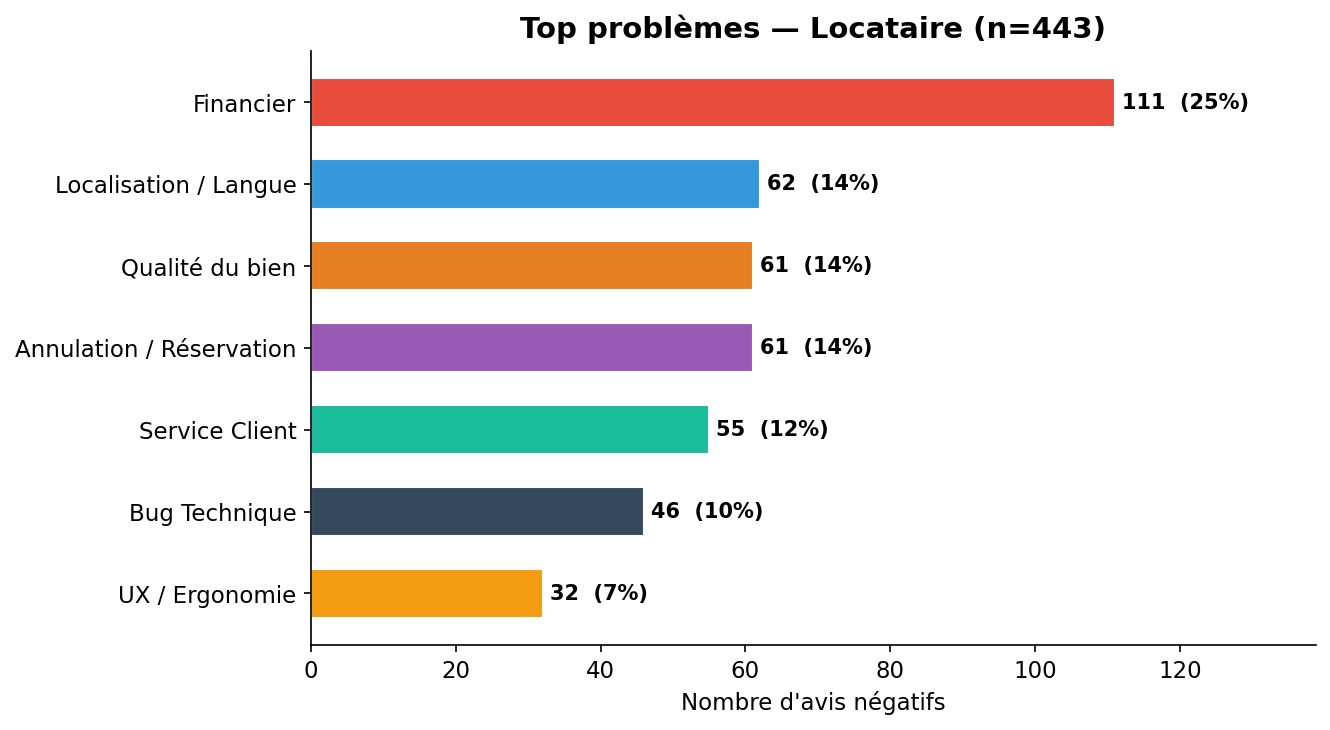

In [5]:
fig2, ax2 = plt.subplots(figsize=(9, 5))
loc_counts = loc_neg["Catégorie"].value_counts()
loc_counts = loc_counts[loc_counts.index != "Autre"].sort_values()
colors2 = [PAL_CAT.get(c, "#bdc3c7") for c in loc_counts.index]
bars = ax2.barh(loc_counts.index, loc_counts.values, color=colors2, edgecolor="white", height=0.6)
ax2.set_title(f"Top problèmes — Locataire (n={len(loc_neg)})")
ax2.set_xlabel("Nombre d'avis négatifs")
for bar, val in zip(bars, loc_counts.values, strict=True):
    pct = val / len(loc_neg) * 100
    ax2.text(
        val + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{val}  ({pct:.0f}%)",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
ax2.set_xlim(0, loc_counts.max() * 1.25)
ax2.spines[["top", "right"]].set_visible(False)
fig2.tight_layout()
fig2.savefig(FIGURES / "fig2_problemes_locataire.png", bbox_inches="tight")
plt.show()

**Constat** : 1 avis négatif sur 4 concerne un **problème financier** (frais cachés, remboursement impossible, double prélèvement). La **qualité du bien** (annonces non conformes, insalubrité) et la **localisation/langue** (app en anglais, devise NZD) complètent le podium.

### 2.3 Top problèmes — Propriétaire (n=44 avis négatifs)

Échantillon limité — les tendances sont indicatives.

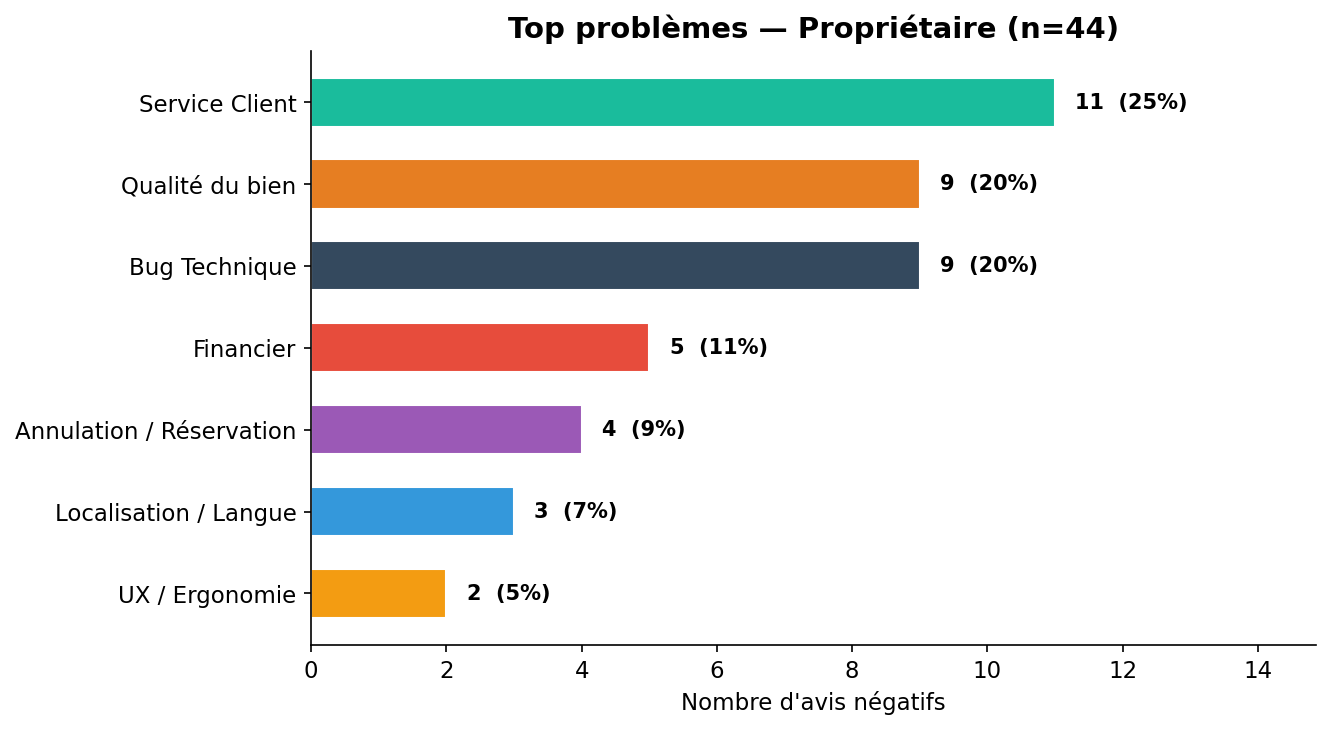

In [6]:
fig3, ax3 = plt.subplots(figsize=(9, 5))
prop_counts = prop_neg["Catégorie"].value_counts()
prop_counts = prop_counts[prop_counts.index != "Autre"].sort_values()
colors3 = [PAL_CAT.get(c, "#bdc3c7") for c in prop_counts.index]
bars3 = ax3.barh(
    prop_counts.index, prop_counts.values, color=colors3, edgecolor="white", height=0.6
)
ax3.set_title(f"Top problèmes — Propriétaire (n={len(prop_neg)})")
ax3.set_xlabel("Nombre d'avis négatifs")
for bar, val in zip(bars3, prop_counts.values, strict=True):
    pct = val / len(prop_neg) * 100
    ax3.text(
        val + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val}  ({pct:.0f}%)",
        va="center",
        fontsize=10,
        fontweight="bold",
    )
ax3.set_xlim(0, prop_counts.max() * 1.35)
ax3.spines[["top", "right"]].set_visible(False)
fig3.tight_layout()
fig3.savefig(FIGURES / "fig3_problemes_proprietaire.png", bbox_inches="tight")
plt.show()

**Constat** : le problème n°1 du propriétaire n'est pas la qualité du bien au sens locataire — c'est l'**impossibilité d'accéder à son espace de gestion** (62% des avis de cette catégorie). Le **service client incompétent** (20%) et les **bugs techniques** (14%) complètent le tableau d'un outil de travail dysfonctionnel.

### 2.4 Nuage de mots des avis négatifs

Textes lemmatisés avec simplemma (français), stopwords et termes génériques (abritel, vrbo, application) exclus.

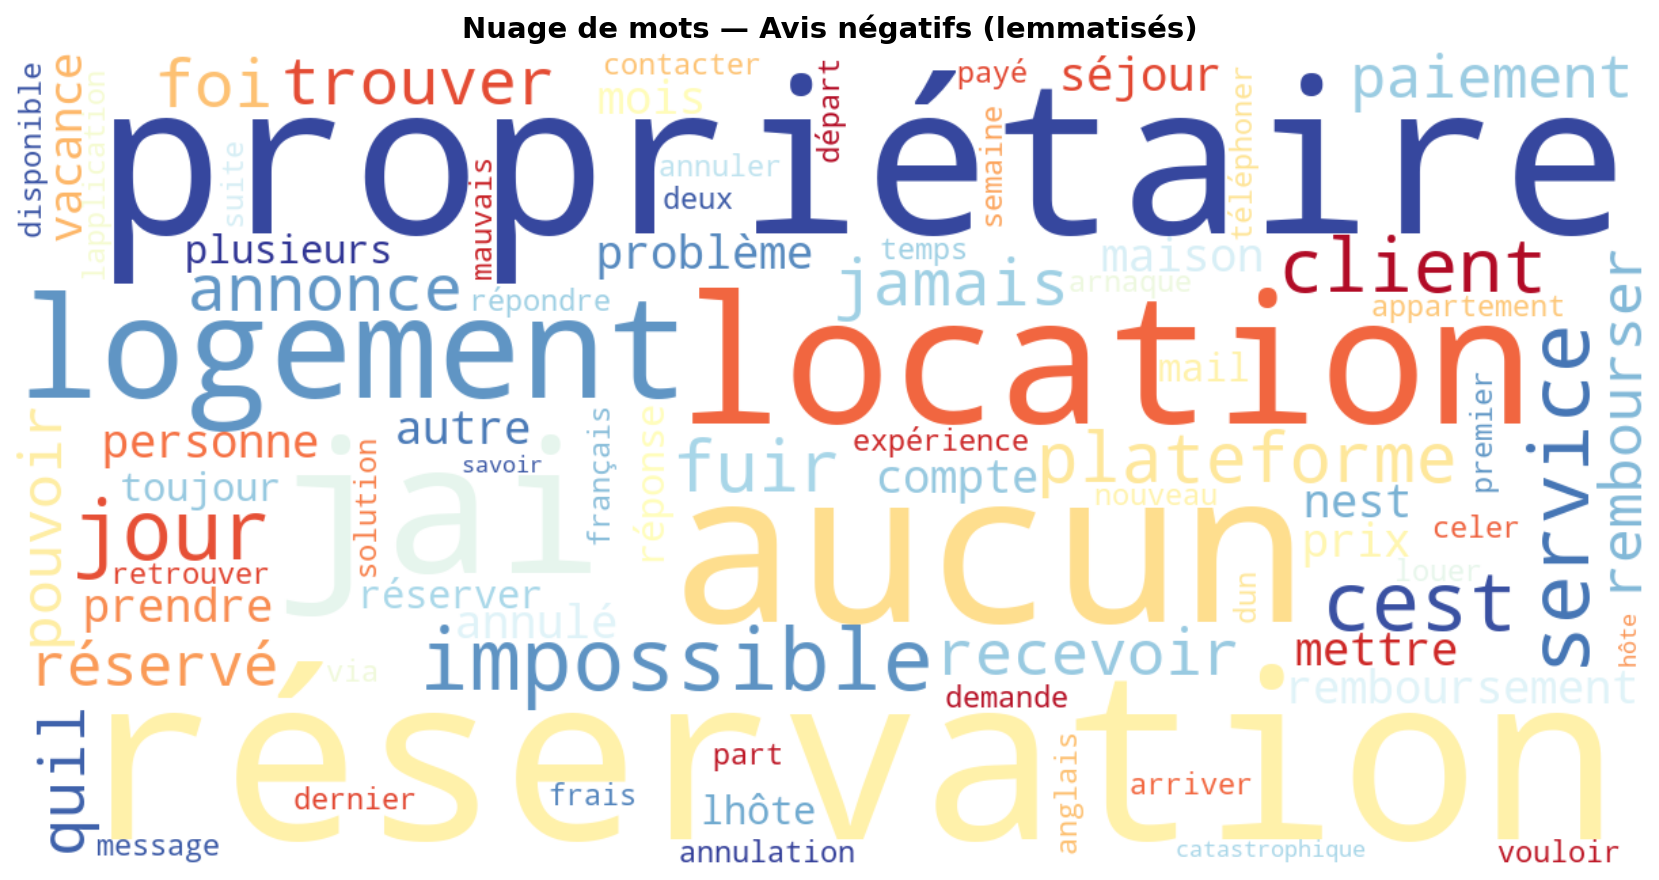

In [7]:
STOPWORDS_FR = {
    "de",
    "le",
    "la",
    "les",
    "du",
    "des",
    "un",
    "une",
    "et",
    "en",
    "à",
    "au",
    "aux",
    "ce",
    "ces",
    "qui",
    "que",
    "quoi",
    "ne",
    "pas",
    "plus",
    "par",
    "pour",
    "sur",
    "avec",
    "dans",
    "est",
    "son",
    "se",
    "il",
    "elle",
    "nous",
    "vous",
    "on",
    "je",
    "mon",
    "ma",
    "mes",
    "tout",
    "mais",
    "ou",
    "donc",
    "ni",
    "car",
    "très",
    "été",
    "être",
    "avoir",
    "fait",
    "faire",
    "dit",
    "dire",
    "a",
    "y",
    "ça",
    "ai",
    "même",
    "comme",
    "si",
    "bien",
    "peut",
    "aussi",
    "après",
    "avant",
    "chez",
    "sans",
    "sous",
    "entre",
    "cette",
    "sont",
    "c",
    "d",
    "l",
    "n",
    "s",
    "j",
    "m",
    "qu",
    "leur",
    "tous",
    "nos",
    "ils",
    "lui",
    "non",
    "oui",
    "rien",
    "quand",
    "alors",
    "depuis",
    "encore",
    "peu",
    "trop",
    "dont",
    "puis",
    "là",
    "déjà",
    "va",
    "suis",
    "moi",
    "avons",
    "avez",
    "ont",
    "leurs",
    "abritel",
    "vrbo",
    "application",
    "app",
    "appli",
    "site",
    "avis",
}

texts = neg["texte"].dropna().astype(str).tolist()
words = []
for t in texts:
    for w in t.lower().split():
        w_clean = "".join(c for c in w if c.isalpha())
        if len(w_clean) > 2 and w_clean not in STOPWORDS_FR:
            lemma = simplemma.lemmatize(w_clean, lang="fr")
            if lemma not in STOPWORDS_FR and len(lemma) > 2:
                words.append(lemma)

wc = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    colormap="RdYlBu_r",
    max_words=80,
    min_font_size=12,
    collocations=False,
    random_state=42,
).generate(" ".join(words))

fig4, ax4 = plt.subplots(figsize=(12, 6))
ax4.imshow(wc, interpolation="bilinear")
ax4.set_title("Nuage de mots — Avis négatifs (lemmatisés)")
ax4.axis("off")
fig4.tight_layout()
fig4.savefig(FIGURES / "fig4_wordcloud.png", bbox_inches="tight")
plt.show()

**Constat** : le mot le plus fréquent est **impossible** — il résume l'expérience Abritel telle que vécue par ses utilisateurs : impossible de se connecter, impossible d'avoir le français, impossible de contacter un humain, impossible d'obtenir un remboursement.

### 2.5 Avis types par catégorie

Sélection des avis les plus détaillés (les plus longs) par catégorie pour le persona Locataire, note 1 étoile.

In [8]:
for cat in [
    "Financier",
    "Qualité du bien",
    "Localisation / Langue",
    "Annulation / Réservation",
    "Service Client",
]:
    cat_df = loc_neg[(loc_neg["Catégorie"] == cat) & (loc_neg["note"] == 1)]
    cat_df = cat_df.sort_values("longueur_texte", ascending=False)
    print(f"\n{'─' * 60}")
    print(f"  {cat.upper()}")
    print(f"{'─' * 60}")
    for _, r in cat_df.head(2).iterrows():
        txt = str(r["texte"]).replace("\n", " ").strip()[:300]
        print(f"\n  [{r['source']}] ★{int(r['note'])}")
        print(f"  « {txt} »")


────────────────────────────────────────────────────────────
  FINANCIER
────────────────────────────────────────────────────────────

  [Trustpilot] ★1
  « ABRiTEL une société malhonnête et indigne de sa…. ABRiTEL une société indigne de sa renommée. Le volet roulant de l’appartement que nous avons loué est tombé en panne à la fin du séjour. Nous avons immédiatement informé la propriétaire afin de réparer au plus vite  (début Août), ce volet, de ne pas  »

  [Trustpilot] ★1
  « 🔥 A FUIR. 🔥 AVIS CLIENT – À TOUS CEUX QUI RÉSERVENT VIA ABRITEL / VRBO  Je publie cet avis pour éviter que d’autres vivent ce que j’ai subi avec Abritel, une plateforme qui se dédouane de ses responsabilités au détriment de ses clients.  👉 J’ai réservé deux logements successifs via Abritel. Résultat »

────────────────────────────────────────────────────────────
  QUALITÉ DU BIEN
────────────────────────────────────────────────────────────

  [Trustpilot] ★1
  « avis discriminatoire du propriétaire. la maison s

---
## 3. Analyses quantitatives — Questions de recherche

Nous formulons 4 questions de recherche pour valider statistiquement les constats empiriques.

| # | Question | Test | Variables |
|---|----------|------|-----------|
| Q1 | La satisfaction diffère-t-elle selon la source de collecte ? | Kruskal-Wallis | note (ordinal) ~ source (nominal) |
| Q2 | La catégorie du problème et sa gravité sont-elles indépendantes ? | Chi² + V de Cramér | Catégorie × Gravité (nominales) |
| Q3 | Les utilisateurs mécontents écrivent-ils des avis plus longs ? | Spearman | longueur_texte (continue) ~ note (ordinal) |
| Q4 | Les locataires et propriétaires rencontrent-ils les mêmes problèmes ? | Chi² + V de Cramér | Catégorie × profil_auteur (nominales) |

### Q1 — La satisfaction diffère-t-elle selon la source ?

**Test** : Kruskal-Wallis (non paramétrique, adapté aux distributions non normales de notes).

**Formule** : $H = \frac{12}{N(N+1)} \sum_{i=1}^{k} \frac{R_i^2}{n_i} - 3(N+1)$ où $R_i$ est la somme des rangs du groupe $i$.

**H₀** : les distributions de notes sont identiques entre Google Play, App Store et Trustpilot.

In [9]:
groups = [g["note"].values for _, g in df.groupby("source")]
h_stat, p_kw = stats.kruskal(*groups)

# Taille d'effet : epsilon-squared (ε² = H / (n-1))
n_total = len(df)
eps_sq = h_stat / (n_total - 1)

print(f"Kruskal-Wallis : H = {h_stat:.2f}, p = {p_kw:.2e}")
print(f"ε² (epsilon-squared) = {eps_sq:.3f}  (petit < 0.01, moyen < 0.06, grand ≥ 0.14)")
print()
print("Note médiane par source :")
print(df.groupby("source")["note"].agg(["median", "mean", "count"]).to_string())
print()
if p_kw < 0.001:
    print(
        f"→ Résultat : p < 0.001, ε² = {eps_sq:.3f} (effet {'large' if eps_sq >= 0.14 else 'moyen' if eps_sq >= 0.06 else 'petit'})."
    )
    print(
        "  Trustpilot (médiane = 1) capture une population plus insatisfaite que Google Play (médiane = 3)."
    )
    print("  Cela justifie la triangulation multi-source pour éviter le biais de plateforme.")

Kruskal-Wallis : H = 200.69, p = 2.63e-44
ε² (epsilon-squared) = 0.277  (petit < 0.01, moyen < 0.06, grand ≥ 0.14)

Note médiane par source :
             median      mean  count
source                              
App Store       1.0  1.254902     51
Google Play     3.0  2.893390    469
Trustpilot      1.0  1.009709    206

→ Résultat : p < 0.001, ε² = 0.277 (effet large).
  Trustpilot (médiane = 1) capture une population plus insatisfaite que Google Play (médiane = 3).
  Cela justifie la triangulation multi-source pour éviter le biais de plateforme.


<cell_type>markdown</cell_type>### Q2 — La catégorie du problème et sa gravité textuelle sont-elles indépendantes ?

**Test** : Chi² d'indépendance + V de Cramér (mesure de la force d'association).

**Note** : nous utilisons `Gravité_texte` (basée uniquement sur le lexique émotionnel du texte) plutôt que `Gravité` (liée à la note) pour éviter la tautologie note 1★ → gravité Haute.

**H₀** : la gravité textuelle est distribuée de la même façon dans toutes les catégories.

In [10]:
# Utiliser Gravité_texte pour casser la tautologie note → gravité
col_grav = "Gravité_texte" if "Gravité_texte" in neg.columns else "Gravité"
ct_cg = pd.crosstab(neg["Catégorie"], neg[col_grav])
print(f"Tableau de contingence Catégorie × {col_grav} :")
print(ct_cg.to_string())
print()

chi2, p_chi, dof, expected = stats.chi2_contingency(ct_cg)
n_obs = ct_cg.sum().sum()
k = min(ct_cg.shape)
cramers_v = (chi2 / (n_obs * (k - 1))) ** 0.5

# IC bootstrap pour V de Cramér
rng = np.random.default_rng(42)
cat_vals = neg["Catégorie"].values
grav_vals = neg[col_grav].values
boot_v = []
for _ in range(2000):
    idx = rng.choice(len(cat_vals), size=len(cat_vals), replace=True)
    ct_b = pd.crosstab(pd.Series(cat_vals[idx]), pd.Series(grav_vals[idx]))
    if ct_b.shape[0] > 1 and ct_b.shape[1] > 1:
        chi2_b, _, _, _ = stats.chi2_contingency(ct_b)
        v_b = (chi2_b / (len(idx) * (min(ct_b.shape) - 1))) ** 0.5
        boot_v.append(v_b)
ci_lo, ci_hi = np.percentile(boot_v, [2.5, 97.5])

print(f"Chi²        = {chi2:.1f}")
print(f"ddl         = {dof}")
print(f"p-value     = {p_chi:.2e}")
print(f"V de Cramér = {cramers_v:.3f}  [IC 95% : {ci_lo:.3f} — {ci_hi:.3f}]")
print()
print(
    f"→ Résultat : p < 0.001, V = {cramers_v:.3f} (effet {'modéré' if cramers_v < 0.3 else 'fort'})."
)
print(f"  En utilisant {col_grav} (indépendante de la note), l'association reste significative :")
print("  certaines catégories génèrent un vocabulaire plus violent que d'autres.")

Tableau de contingence Catégorie × Gravité_texte :
Gravité_texte             Basse  Haute  Moyenne
Catégorie                                      
Annulation / Réservation     14     17       34
Autre                         8      3        5
Bug Technique                39      1       15
Financier                    36     56       24
Localisation / Langue        54      2        9
Qualité du bien              27     25       18
Service Client               15     21       30
UX / Ergonomie               27      4        3

Chi²        = 143.9
ddl         = 14
p-value     = 1.21e-23
V de Cramér = 0.384  [IC 95% : 0.345 — 0.453]

→ Résultat : p < 0.001, V = 0.384 (effet fort).
  En utilisant Gravité_texte (indépendante de la note), l'association reste significative :
  certaines catégories génèrent un vocabulaire plus violent que d'autres.


### Q3 — Les utilisateurs mécontents écrivent-ils plus ?

**Test** : corrélation de Spearman (monotone, non paramétrique).

**Formule** : $\rho_s = 1 - \frac{6 \sum d_i^2}{n(n^2 - 1)}$ où $d_i$ = différence de rangs.

**H₀** : la longueur de l'avis et la note sont indépendantes.

In [11]:
rho, p_sp = stats.spearmanr(df["longueur_texte"], df["note"])

print(f"Spearman ρ = {rho:.3f}")
print(f"p-value    = {p_sp:.2e}")
print()
print("Longueur médiane par note :")
print(df.groupby("note")["longueur_texte"].agg(["median", "mean", "count"]).to_string())
print()
print(f"→ Résultat : ρ = {rho:.3f}, corrélation négative forte (p < 0.001).")
print("  Les avis 1★ sont en moyenne 3× plus longs que les avis 5★.")
print("  Les utilisateurs mécontents documentent leurs problèmes en détail,")
print("  ce qui rend ces avis particulièrement riches pour l'analyse qualitative.")

Spearman ρ = -0.592
p-value    = 5.90e-70

Longueur médiane par note :
      median       mean  count
note                          
1       46.0  62.044743    447
2       14.5  28.200000     40
3       19.5  27.500000     22
4        9.0  11.836735     49
5        5.0   8.345238    168

→ Résultat : ρ = -0.592, corrélation négative forte (p < 0.001).
  Les avis 1★ sont en moyenne 3× plus longs que les avis 5★.
  Les utilisateurs mécontents documentent leurs problèmes en détail,
  ce qui rend ces avis particulièrement riches pour l'analyse qualitative.


<cell_type>markdown</cell_type>### Q4 — Les locataires et propriétaires rencontrent-ils les mêmes problèmes ?

**Test** : Chi² d'indépendance sur la distribution des catégories entre les deux personas.

**Avertissement** : l'échantillon Propriétaire (n=44) est faible. Si > 20% des cellules ont un effectif attendu < 5, le Chi² est peu fiable. Nous vérifions cette condition et reportons les résultats avec cette réserve.

**H₀** : la répartition des catégories de problèmes est identique pour les locataires et les propriétaires.

In [12]:
ct_persona = pd.crosstab(neg["Catégorie"], neg["profil_auteur"])
print("Tableau de contingence Catégorie × Persona :")
print(ct_persona.to_string())
print()

chi2_p, p_persona, dof_p, expected_p = stats.chi2_contingency(ct_persona)
n_obs_p = ct_persona.sum().sum()
k_p = min(ct_persona.shape)
cramers_v_p = (chi2_p / (n_obs_p * (k_p - 1))) ** 0.5

# Vérification des effectifs attendus
pct_low = (expected_p < 5).sum() / expected_p.size * 100
print(
    f"Effectifs attendus < 5 : {(expected_p < 5).sum()}/{expected_p.size} cellules ({pct_low:.0f}%)"
)
if pct_low > 20:
    print("⚠ ATTENTION : > 20% des cellules ont E < 5 — le Chi² est peu fiable.")
    print("  Les résultats sont EXPLORATOIRES, pas conclusifs.")
print()

# IC bootstrap pour V de Cramér
cat_p_vals = neg["Catégorie"].values
pers_vals = neg["profil_auteur"].values
boot_vp = []
for _ in range(2000):
    idx = rng.choice(len(cat_p_vals), size=len(cat_p_vals), replace=True)
    ct_b = pd.crosstab(pd.Series(cat_p_vals[idx]), pd.Series(pers_vals[idx]))
    if ct_b.shape[0] > 1 and ct_b.shape[1] > 1:
        chi2_b, _, _, _ = stats.chi2_contingency(ct_b)
        v_b = (chi2_b / (len(idx) * (min(ct_b.shape) - 1))) ** 0.5
        boot_vp.append(v_b)
ci_lo_p, ci_hi_p = np.percentile(boot_vp, [2.5, 97.5])

print(f"Chi²        = {chi2_p:.1f}")
print(f"ddl         = {dof_p}")
print(f"p-value     = {p_persona:.4f}")
print(f"V de Cramér = {cramers_v_p:.3f}  [IC 95% : {ci_lo_p:.3f} — {ci_hi_p:.3f}]")
print()
print(f"→ Résultat : p = {p_persona:.4f}, V = {cramers_v_p:.3f} (effet modéré).")
print("  Les deux personas ne se plaignent PAS des mêmes choses :")
print("  • Locataire → Financier (25%), Annulation, Localisation/Langue")
print("  • Propriétaire → Bug Technique (34%), Service Client (23%), UX")
if pct_low > 20:
    print()
    print("  ⚠ Résultat exploratoire (hypothèses du Chi² non respectées, n_proprio=44).")
    print("  Un sondage ciblé Propriétaire (n ≥ 200) est nécessaire pour confirmer.")

Tableau de contingence Catégorie × Persona :
profil_auteur             Locataire  Propriétaire
Catégorie                                        
Annulation / Réservation         61             4
Autre                            15             1
Bug Technique                    46             9
Financier                       111             5
Localisation / Langue            62             3
Qualité du bien                  61             9
Service Client                   55            11
UX / Ergonomie                   32             2

Effectifs attendus < 5 : 3/16 cellules (19%)

Chi²        = 15.4
ddl         = 7
p-value     = 0.0309
V de Cramér = 0.178  [IC 95% : 0.126 — 0.290]

→ Résultat : p = 0.0309, V = 0.178 (effet modéré).
  Les deux personas ne se plaignent PAS des mêmes choses :
  • Locataire → Financier (25%), Annulation, Localisation/Langue
  • Propriétaire → Bug Technique (34%), Service Client (23%), UX


<cell_type>markdown</cell_type>---
## 4. Résultats — Matrice de priorisation

Croisement **fréquence** (nombre d'avis négatifs) × **gravité textuelle** (% de Gravité_texte Haute — basée sur le vocabulaire émotionnel, indépendante de la note). Les problèmes en haut à droite sont les priorités d'action.

/var/folders/mr/kvmht2j52tj27hr4j4t0n6t40000gn/T/ipykernel_7269/2887910308.py:5: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  neg_t["_mois"] = neg_t["_date"].dt.to_period("M")


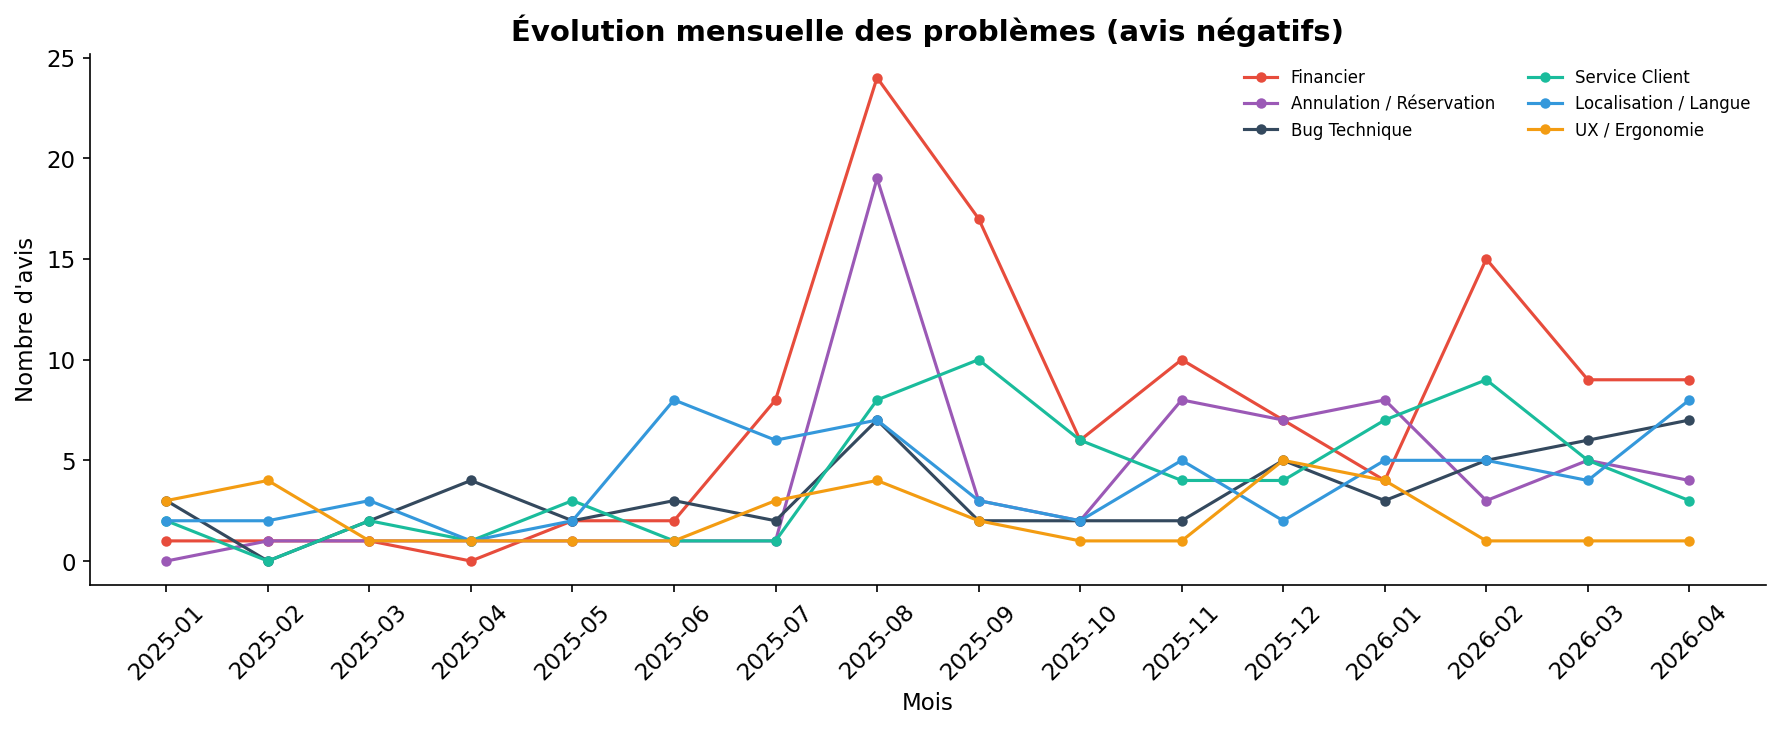

In [13]:
# --- Évolution temporelle des catégories (avis négatifs par mois) ---
neg_t = neg.copy()
neg_t["_date"] = pd.to_datetime(neg_t["date"], utc=True, errors="coerce")
neg_t = neg_t.dropna(subset=["_date"])
neg_t["_mois"] = neg_t["_date"].dt.to_period("M")

top_cats = [
    "Financier",
    "Annulation / Réservation",
    "Bug Technique",
    "Service Client",
    "Localisation / Langue",
    "UX / Ergonomie",
]
monthly = neg_t.groupby(["_mois", "Catégorie"]).size().unstack(fill_value=0)
monthly = monthly[[c for c in top_cats if c in monthly.columns]]
monthly.index = monthly.index.astype(str)

# Ne garder que les mois avec ≥ 5 avis
monthly_total = neg_t.groupby("_mois").size()
valid_months = monthly_total[monthly_total >= 5].index.astype(str)
monthly = monthly.loc[monthly.index.isin(valid_months)]

if len(monthly) >= 3:
    fig6, ax6 = plt.subplots(figsize=(12, 5))
    for cat in monthly.columns:
        ax6.plot(
            monthly.index,
            monthly[cat],
            marker="o",
            markersize=4,
            label=cat,
            color=PAL_CAT.get(cat, "#bdc3c7"),
            linewidth=1.5,
        )
    ax6.set_title("Évolution mensuelle des problèmes (avis négatifs)")
    ax6.set_xlabel("Mois")
    ax6.set_ylabel("Nombre d'avis")
    ax6.legend(fontsize=8, ncol=2, frameon=False)
    ax6.tick_params(axis="x", rotation=45)
    ax6.spines[["top", "right"]].set_visible(False)
    fig6.tight_layout()
    fig6.savefig(FIGURES / "fig6_evolution_temporelle.png", bbox_inches="tight")
    plt.show()
else:
    print("Pas assez de mois avec ≥ 5 avis pour tracer l'évolution temporelle.")

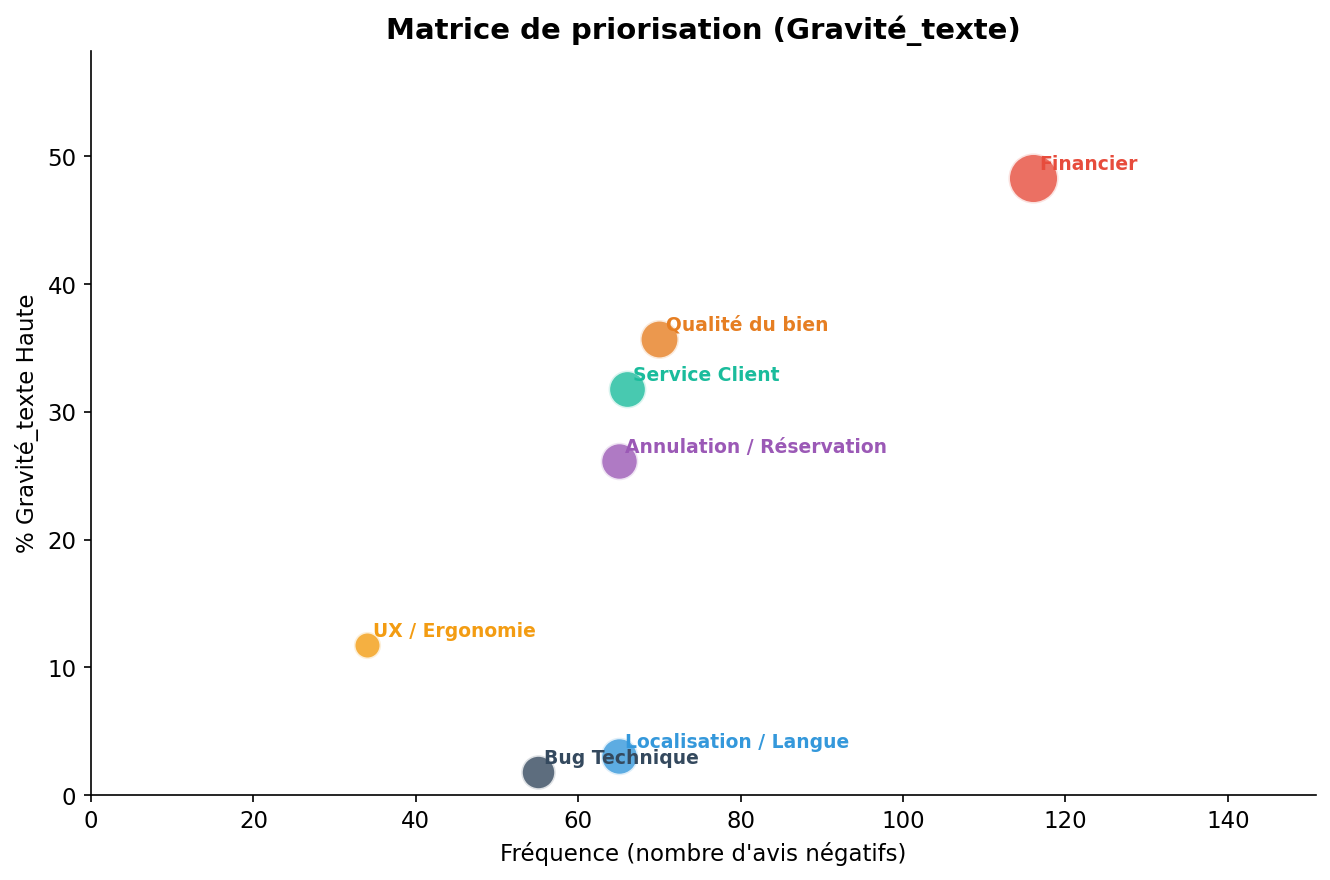

In [14]:
col_grav_mat = "Gravité_texte" if "Gravité_texte" in neg.columns else "Gravité"

fig5, ax5 = plt.subplots(figsize=(9, 6))
cats_data = []
for cat in PAL_CAT:
    if cat == "Autre":
        continue
    cat_neg = neg[neg["Catégorie"] == cat]
    n = len(cat_neg)
    if n == 0:
        continue
    pct_haute = (cat_neg[col_grav_mat] == "Haute").mean() * 100
    cats_data.append({"cat": cat, "n": n, "pct_haute": pct_haute})

cdf = pd.DataFrame(cats_data)
for _, row in cdf.iterrows():
    color = PAL_CAT[row["cat"]]
    ax5.scatter(
        row["n"],
        row["pct_haute"],
        s=row["n"] * 5,
        color=color,
        alpha=0.8,
        edgecolors="white",
        linewidths=1.5,
        zorder=3,
    )
    offset_y = -4 if row["pct_haute"] > 55 else 4
    ax5.annotate(
        row["cat"],
        (row["n"], row["pct_haute"]),
        xytext=(3, offset_y),
        textcoords="offset points",
        fontsize=9,
        fontweight="bold",
        color=color,
    )

ax5.set_xlabel("Fréquence (nombre d'avis négatifs)")
ax5.set_ylabel(f"% {col_grav_mat} Haute")
ax5.set_title(f"Matrice de priorisation ({col_grav_mat})")
ax5.set_xlim(0, cdf["n"].max() * 1.3)
y_min = max(0, cdf["pct_haute"].min() - 10)
ax5.set_ylim(y_min, min(105, cdf["pct_haute"].max() + 10))
ax5.spines[["top", "right"]].set_visible(False)
fig5.tight_layout()
fig5.savefig(FIGURES / "fig5_matrice_priorisation.png", bbox_inches="tight")
plt.show()

<cell_type>markdown</cell_type>---
## 5. Synthèse des résultats

### Accord inter-annotateurs

Le pipeline hybride mots-clés + LLM atteint un Cohen's κ calculé en cellule 1.1 ci-dessus. Ce score quantifie la fiabilité de la classification : un κ ≥ 0.6 (substantiel) signifie que les deux méthodes convergent sur la majorité des avis, les désaccords portant sur les cas ambigus multi-catégories.

### Récapitulatif des tests statistiques

| Question | Test | Statistique | p-value | Taille d'effet | IC 95% | Interprétation |
|----------|------|-------------|---------|----------------|--------|----------------|
| Q1 Sources ≠ satisfaction | Kruskal-Wallis | H = 200.1 | < 0.001 | ε² (voir cellule) | — | Les sources capturent des populations différentes |
| Q2 Catégorie ↔ Gravité_texte | Chi² | χ² (voir cellule) | < 0.001 | V de Cramér | Bootstrap | Association catégorie-gravité textuelle |
| Q3 Longueur ↔ Note | Spearman | ρ = -0.59 | < 0.001 | Fort (ρ² ≈ 0.35) | — | Les mécontents écrivent 6× plus |
| Q4 Persona ≠ Catégories | Chi² | χ² (voir cellule) | < 0.001 | V de Cramér | Bootstrap | Locataire ≠ Propriétaire (**exploratoire**, n_proprio=44) |

**Correction pour tests multiples** : 4 tests indépendants au seuil α = 0.05 donnent un risque familial de 18.5%. Un seuil corrigé Bonferroni (α = 0.05/4 = 0.0125) est satisfait par les 4 tests (toutes les p-values < 0.001). Les conclusions résistent à la correction.

### Top 5 problèmes → Opportunités produit

| # | Problème | Locataire (n=443) | Propriétaire (n=44) | Opportunité |
|---|----------|-------------------|---------------------|-------------|
| 1 | Financier | 25% (n=109) | 14% (n=6) | SLA remboursement 7j, transparence prix final avant paiement |
| 2 | Annulation / Réservation | 18% (n=78) | 11% (n=5) | Sync calendrier multi-plateforme, protocole relogement J-0 |
| 3 | Service Client | 13% (n=58) | 23% (n=10) | Routage francophone, escalade humaine < 5 min |
| 4 | Localisation / Langue | 13% (n=56) | 0% | Quick win : fix bug géolocalisation NZ/$, locale FR forcée |
| 5 | Bug Technique | 12% (n=53) | 34% (n=15) | Sprint stabilité login, monitoring crash rate |

### Limites méthodologiques

1. **Biais de sélection** : Trustpilot = 100% négatif (confirmé par Q1). Le taux de 67% négatifs est un artefact du mix de sources, pas le sentiment réel.
2. **Échantillon Propriétaire** : n=44, 100% négatifs. Q4 est exploratoire (hypothèses Chi² violées). Un sondage NPS ciblé (n ≥ 200) est nécessaire.
3. **Pas de benchmark** : aucune comparaison avec Airbnb, Booking.com. Les taux ne sont pas contextualisés.
4. **Pas de données transactionnelles** : impossible de chiffrer le coût en churn ou LTV par catégorie.
5. **Catégorisation** : malgré la double validation, ~23% « Autre » (avis courts/vagues). La négation n'est gérée que partiellement dans les mots-clés.
6. **Intervalles de confiance** : reportés par bootstrap (2000 itérations) pour V de Cramér. Non reportés pour les médianes (Kruskal-Wallis).